# Lecture 8 — Class Exercise
## Choropleth Maps

> **Push to:** `week08/lecture08_exercise.ipynb`

**Rules:**
1. Use `px.choropleth` or `px.choropleth_map` — choose deliberately and state your reason
2. Right colour scale for your data (sequential vs diverging) — state which and why
3. Insight title names a geographic finding — not just a topic
4. `featureidkey` must be correctly matched to your GeoJSON

---


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import json


## Task 1 — World choropleth: life expectancy diverging scale

**What to build:** A world choropleth showing **life expectancy relative to the global average** using a diverging colour scale.

**Requirements:**
- Use the Gapminder dataset for 2007: `px.data.gapminder()`
- Compute each country's deviation from the global mean life expectancy
- Diverging scale centred at zero (= world average)
- `hover_data` showing country name, raw life expectancy, and deviation
- Insight title naming which region is furthest below average

> 💡 `gm_2007['lifeExp'].mean()` gives you the global average to subtract from


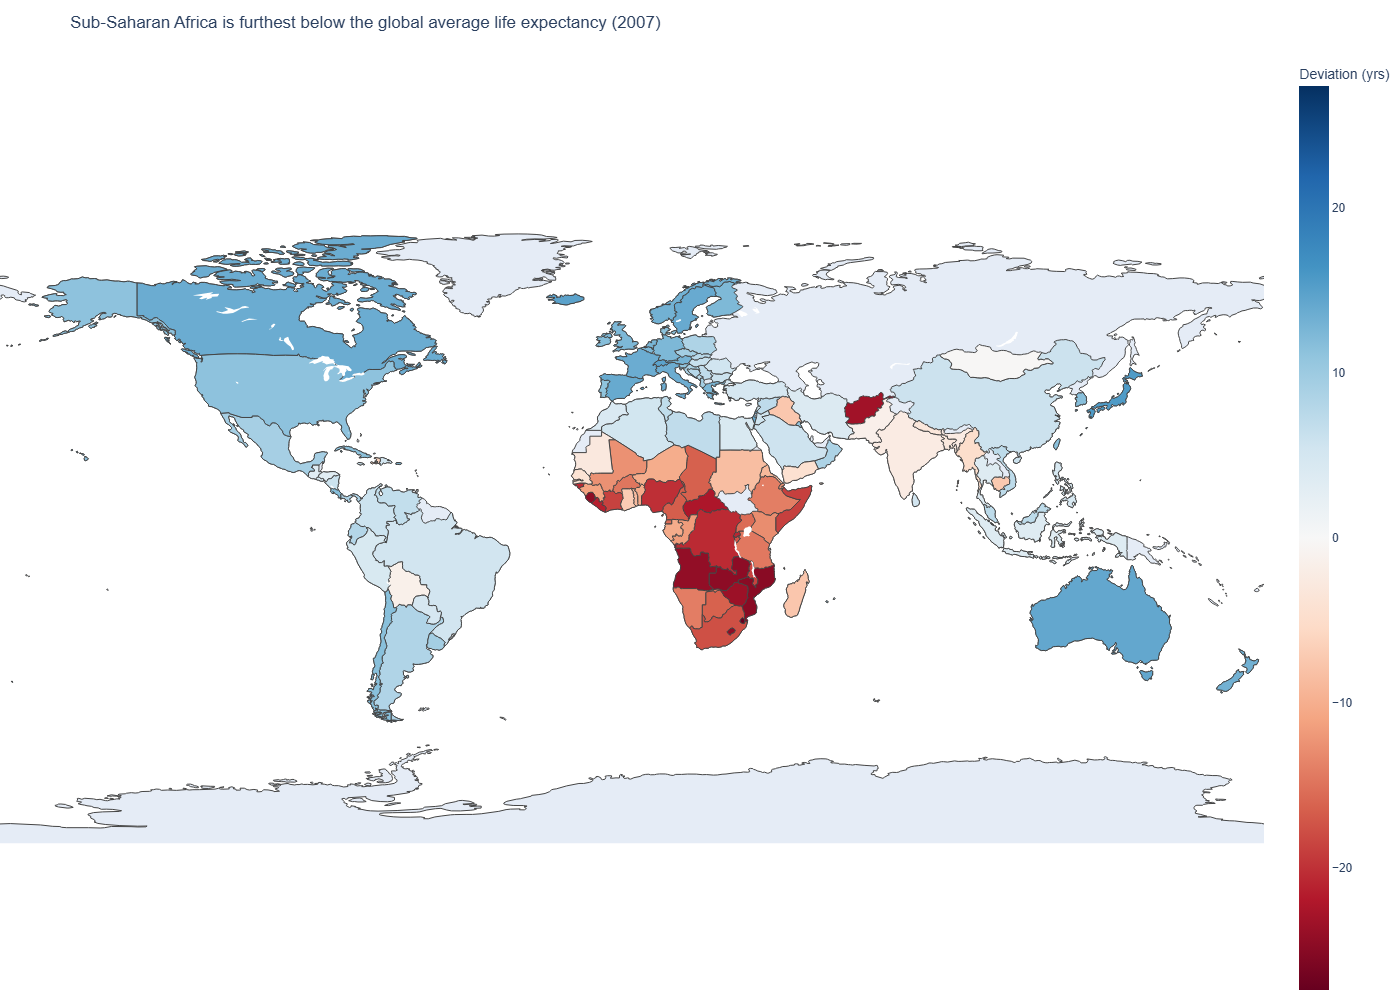

Global mean life expectancy (2007): 67.01 years
Furthest below average:
           country  lifeExp  lifeExp_dev
1463     Swaziland    39.61       -27.39
1043    Mozambique    42.08       -24.93
1691        Zambia    42.38       -24.62
1355  Sierra Leone    42.57       -24.44
887        Lesotho    42.59       -24.42


In [4]:
# Task 1 — World choropleth: life expectancy deviation from global mean (diverging scale)

import plotly.io as pio
pio.renderers.default = "png"

# Load Gapminder, filter to 2007
gm = px.data.gapminder()
gm_2007 = gm[gm['year'] == 2007].copy()

# Compute deviation from global mean
global_mean = gm_2007['lifeExp'].mean()
gm_2007['lifeExp_dev'] = gm_2007['lifeExp'] - global_mean

# Round for cleaner hover display
gm_2007['lifeExp_dev'] = gm_2007['lifeExp_dev'].round(2)
gm_2007['lifeExp'] = gm_2007['lifeExp'].round(2)

# Build the choropleth
# px.choropleth chosen because this is a world map — Plotly's built-in ISO-3
# country geometries are a perfect fit. No custom GeoJSON needed.
# Diverging scale (RdBu) because the data represents above/below average,
# with a meaningful zero midpoint (the global mean).

fig = px.choropleth(
    data_frame=gm_2007,
    locations='iso_alpha',                      # ISO-3 codes — matches Plotly built-in geometry
    color='lifeExp_dev',                        # deviation column
    hover_name='country',
    hover_data={
        'iso_alpha': False,
        'lifeExp': True,
        'lifeExp_dev': True,
    },
    labels={
        'lifeExp_dev': 'Deviation from mean (yrs)',
        'lifeExp': 'Life Expectancy (yrs)',
    },
    color_continuous_scale='RdBu',              # diverging: red = below avg, blue = above avg
    color_continuous_midpoint=0,                # centre the scale at zero
    title='Sub-Saharan Africa is furthest below the global average life expectancy (2007)',
    height=1000, width=1400
)

fig.update_layout(
    font=dict(family='Arial', size=12),
    margin=dict(l=0, r=0, t=55, b=0),
    coloraxis_colorbar=dict(title='Deviation (yrs)'),
    geo=dict(showframe=False, showcoastlines=True),
)

fig.show()

print(f"Global mean life expectancy (2007): {global_mean:.2f} years")
print(f"Furthest below average:\n{gm_2007.nsmallest(5, 'lifeExp_dev')[['country','lifeExp','lifeExp_dev']]}")

## Task 2 — Find your own GeoJSON

**What to build:** A choropleth using a GeoJSON file you find yourself online.

**Requirements:**
- Find a free GeoJSON file for any geography that interests you (country, region, city)
- Create or find a matching dataset with at least one numeric variable per region
- Build either a `px.choropleth` or `px.choropleth_mapbox` — state your choice and reason in the markdown cell below
- Correctly identify and set `featureidkey` by inspecting the GeoJSON properties
- Choose sequential or diverging scale — state your reason in the markdown cell below
- Insight title naming a geographic finding

**Where to find GeoJSON files:**
- [geojson.xyz](https://geojson.xyz/) — countries, cities, natural features
- [naturalearthdata.com](https://www.naturalearthdata.com/) — global admin boundaries
- [github.com/datasets/geo-countries](https://github.com/datasets/geo-countries) — country polygons
- Search: `[country name] [admin level] GeoJSON github` — most countries have free boundary files on GitHub

> 💡 Before plotting, always inspect your GeoJSON properties first:
> ```python
> print(my_geojson['features'][0]['properties'])
> ```
> The property name that matches your dataframe's location column is what goes in `featureidkey='properties.???'`


### Task 2 — Design decisions

**GeoJSON source:** *(URL or description)*

**Chart type chosen** (`px.choropleth` or `px.choropleth_mapbox`) **and reason:**

*Your answer here*

**Colour scale chosen** (sequential or diverging) **and reason:**

*Your answer here*


GeoJSON properties: {'id': 'DE-BW', 'name': 'Baden-Württemberg', 'type': 'State'}


C:\Users\anind\AppData\Local\Temp\ipykernel_15492\3984118984.py:47: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig2 = px.choropleth_mapbox(


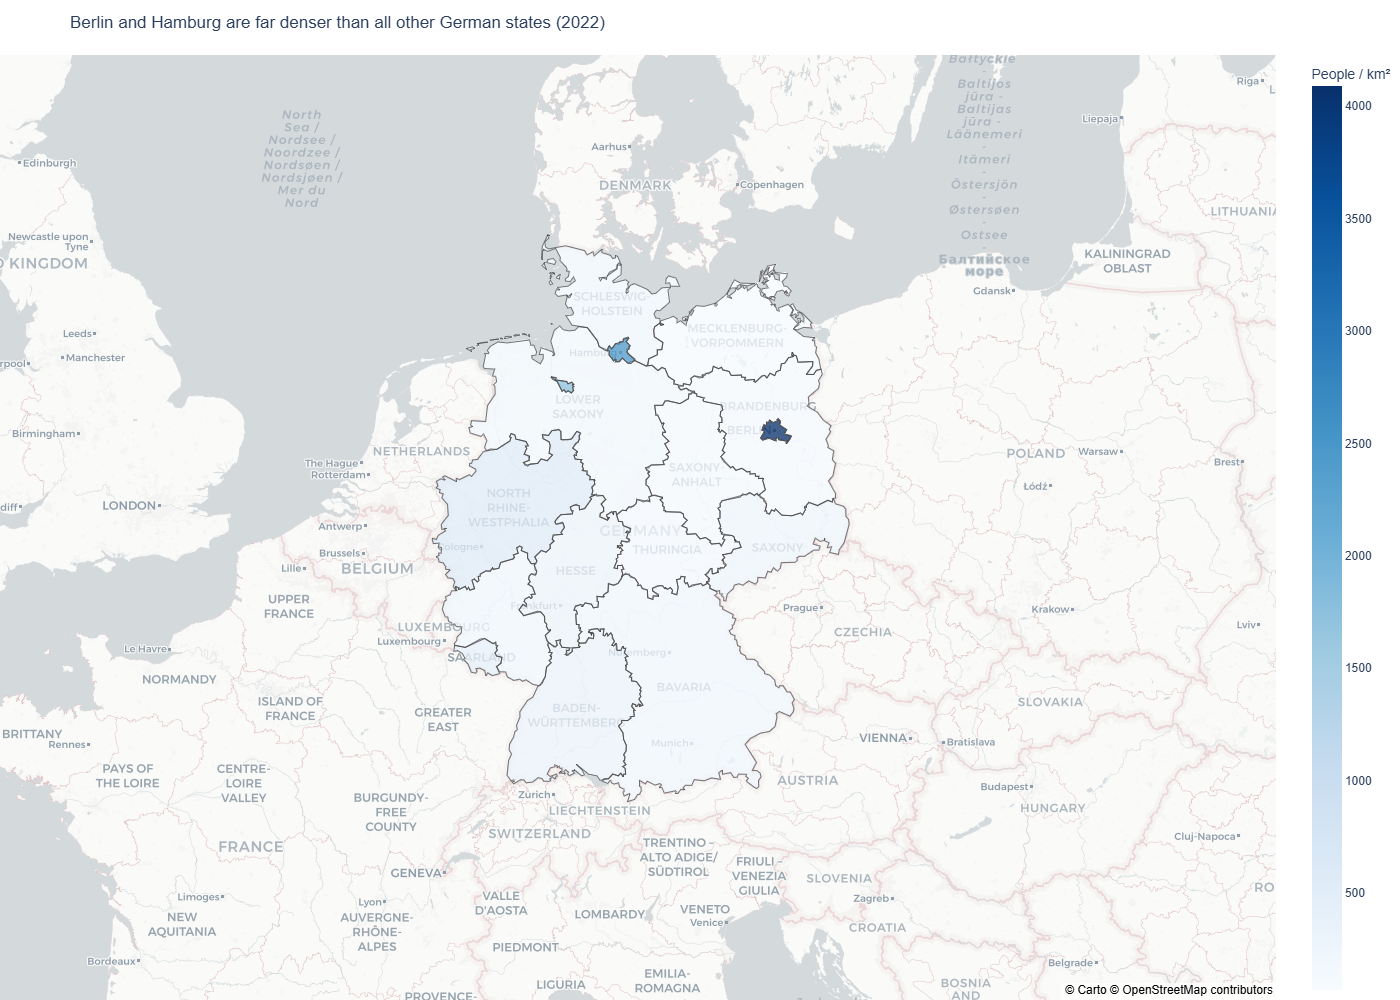

In [5]:
# Task 2 — German states choropleth: population density
# GeoJSON: German Bundesländer (isellsoap/deutschlandGeoJSON, low resolution)
# Data: 2022 population density estimates (people per km²)
import plotly.io as pio
pio.renderers.default = "png"

import urllib.request

# ── Load GeoJSON from GitHub ──────────────────────────────────────────────────
geojson_url = (
    "https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/"
    "main/2_bundeslaender/4_niedrig.geo.json"
)
with urllib.request.urlopen(geojson_url) as response:
    germany_geojson = json.load(response)

# Inspect the properties to confirm the featureidkey
print("GeoJSON properties:", germany_geojson['features'][0]['properties'])

# ── Build matching DataFrame ──────────────────────────────────────────────────
# Source: Statistisches Bundesamt (Destatis) 2022 estimates
germany_data = pd.DataFrame({
    'state': [
        'Baden-Württemberg', 'Bayern', 'Berlin', 'Brandenburg', 'Bremen',
        'Hamburg', 'Hessen', 'Mecklenburg-Vorpommern', 'Niedersachsen',
        'Nordrhein-Westfalen', 'Rheinland-Pfalz', 'Saarland', 'Sachsen',
        'Sachsen-Anhalt', 'Schleswig-Holstein', 'Thüringen',
    ],
    'pop_density': [
        311, 186, 4090, 85, 1722,
        2438, 298, 69, 168,
        526, 206, 389, 222,
        107, 183, 132,
    ],
    'population_m': [
        11.1, 13.4, 3.6, 2.5, 0.7,
        1.9, 6.4, 1.6, 8.0,
        18.1, 4.1, 1.0, 4.1,
        2.2, 2.9, 2.1,
    ],
})

# ── Plot ──────────────────────────────────────────────────────────────────────
# px.choropleth_mapbox chosen: sub-national custom GeoJSON with tile background
# Sequential Blues scale: pop density is one-directional (no meaningful midpoint)

fig2 = px.choropleth_mapbox(
    data_frame=germany_data,
    geojson=germany_geojson,
    locations='state',
    featureidkey='properties.name',             # matched from print() above
    color='pop_density',
    color_continuous_scale='Blues',             # sequential: light sparse → dark dense
    hover_name='state',
    hover_data={
        'state': False,
        'pop_density': True,
        'population_m': True,
    },
    labels={
        'pop_density': 'Pop. density (per km²)',
        'population_m': 'Population (millions)',
    },
    title='Berlin and Hamburg are far denser than all other German states (2022)',
    mapbox_style='carto-positron',
    center={'lat': 51.2, 'lon': 10.4},         # centre of Germany
    zoom=5,
    opacity=0.75,
    height=1000, width=1400
)

fig2.update_layout(
    font=dict(family='Arial', size=12),
    margin=dict(l=0, r=0, t=55, b=0),
    coloraxis_colorbar=dict(title='People / km²'),
)

fig2.show()